# Can Spotify Audio Features Explain Song Popularity?

This notebook cleans and analyses a public Spotify tracks dataset to explore whether audio features such as danceability, energy, valence, acousticness and tempo are associated with song popularity. The outputs from this notebook are used to build the final website blog.

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("data/raw/spotify-tracks-dataset-detailed.csv")

## Data Loading

The raw dataset is loaded from the `data/raw` folder. The first row is skipped because the CSV export added a title row above the actual column names.

In [186]:
df = pd.read_csv(DATA_PATH, low_memory=False, skiprows=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Initial Data Checks

I check the dataset shape, column types, missing values and summary statistics to confirm that the data is usable before cleaning.

In [189]:
df.shape

(114000, 20)

In [191]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [195]:
df.isna().sum().sort_values(ascending=False)

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [197]:
audio_features = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

df[audio_features].describe()

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,-8.258960,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837
std,22.305078,1.072977e+05,0.173542,0.251529,5.029337,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197
min,0.000000,0.000000e+00,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750
50%,35.000000,2.129060e+05,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,50.000000,2.615060e+05,0.695000,0.854000,-5.003000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000
max,100.000000,5.237295e+06,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


## Data Cleaning

Rows with missing core track information are removed, and duplicate tracks are dropped using `track_id`. I also create a duration variable in minutes and define a popular song as a track in the top 25% of the popularity distribution.

In [200]:
df_clean = df.copy()

# Remove rows with missing basic track information
df_clean = df_clean.dropna(subset=["track_id", "artists", "album_name", "track_name"])

# Remove duplicate tracks using track_id
df_clean = df_clean.drop_duplicates(subset="track_id")

# Create a duration variable in minutes for easier interpretation
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

# Define popular songs as tracks in the top 25% of the popularity distribution
popularity_cutoff = df_clean["popularity"].quantile(0.75)
df_clean["popular_song"] = (df_clean["popularity"] >= popularity_cutoff).astype(int)

print("Rows after cleaning:", df_clean.shape[0])
print("Popularity cutoff:", popularity_cutoff)
print(df_clean["popular_song"].value_counts())

Rows after cleaning: 89740
Popularity cutoff: 49.0
popular_song
0    67220
1    22520
Name: count, dtype: int64


In [202]:
CLEAN_PATH = Path("data/cleaned/spotify_tracks_cleaned.csv")
df_clean.to_csv(CLEAN_PATH, index=False)

CLEAN_PATH

PosixPath('data/cleaned/spotify_tracks_cleaned.csv')

## Output 1: Dataset Summary

This table summarises the size of the raw and cleaned datasets, the number of genres and artists, and the cutoff used to define popular songs.

In [204]:
summary_table = pd.DataFrame({
    "Metric": [
        "Raw tracks",
        "Tracks after cleaning",
        "Number of genres",
        "Number of artists",
        "Popularity cutoff for popular songs",
        "Popular songs",
        "Less popular songs"
    ],
    "Value": [
        len(df),
        len(df_clean),
        df_clean["track_genre"].nunique(),
        df_clean["artists"].nunique(),
        popularity_cutoff,
        df_clean["popular_song"].sum(),
        (df_clean["popular_song"] == 0).sum()
    ]
})

summary_table

,Metric,Value
0,Raw tracks,114000.0
1,Tracks after cleaning,89740.0
2,Number of genres,113.0
3,Number of artists,31437.0
4,Popularity cutoff for popular songs,49.0
5,Popular songs,22520.0
6,Less popular songs,67220.0


## Output 2: Popularity Distribution

This chart shows how Spotify popularity scores are distributed across the cleaned dataset. The dashed line marks the cutoff for the top 25% of tracks.

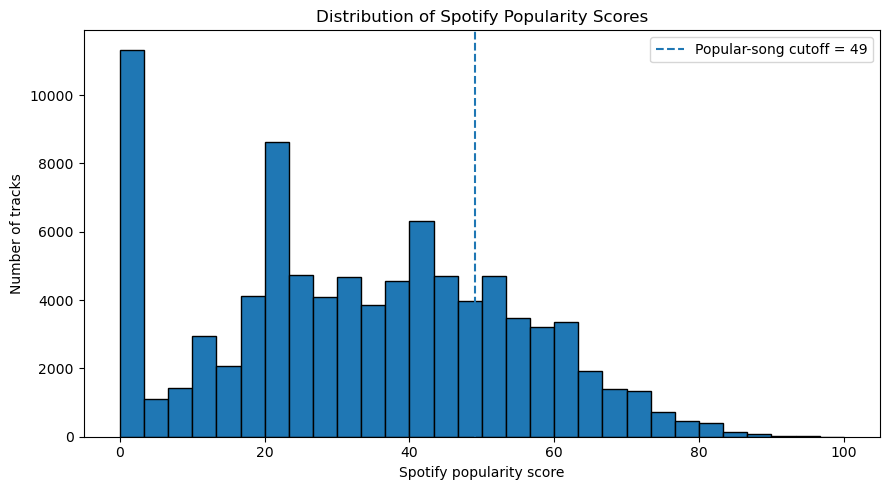

In [208]:
plt.figure(figsize=(9, 5))

plt.hist(df_clean["popularity"], bins=30, edgecolor="black")
plt.axvline(popularity_cutoff, linestyle="--", label=f"Popular-song cutoff = {popularity_cutoff:.0f}")

plt.title("Distribution of Spotify Popularity Scores")
plt.xlabel("Spotify popularity score")
plt.ylabel("Number of tracks")
plt.legend()
plt.tight_layout()

plt.savefig("figures/popularity_distribution.png", dpi=300)
plt.show()

## Output 3: Popular vs Less Popular Songs

This table compares the average audio features of popular and less popular songs.

In [211]:
feature_compare = df_clean.groupby("popular_song")[[
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness", "duration_min"
]].mean().T

feature_compare.columns = ["Less popular", "Popular"]
feature_compare["Difference"] = feature_compare["Popular"] - feature_compare["Less popular"]

feature_compare.sort_values("Difference", ascending=False)

,Less popular,Popular,Difference
danceability,0.556446,0.579241,0.022796
speechiness,0.091011,0.076790,-0.014221
energy,0.638587,0.622136,-0.016451
acousticness,0.334661,0.309255,-0.025406
valence,0.476057,0.449826,-0.026231
liveness,0.226777,0.187701,-0.039076
instrumentalness,0.189077,0.126668,-0.062409
duration_min,3.866675,3.676984,-0.189691


## Output 4: Audio Feature Differences

This chart visualises which audio features are higher or lower on average among popular songs compared with less popular songs. Duration is excluded here because it is measured on a different scale from the 0–1 audio features.

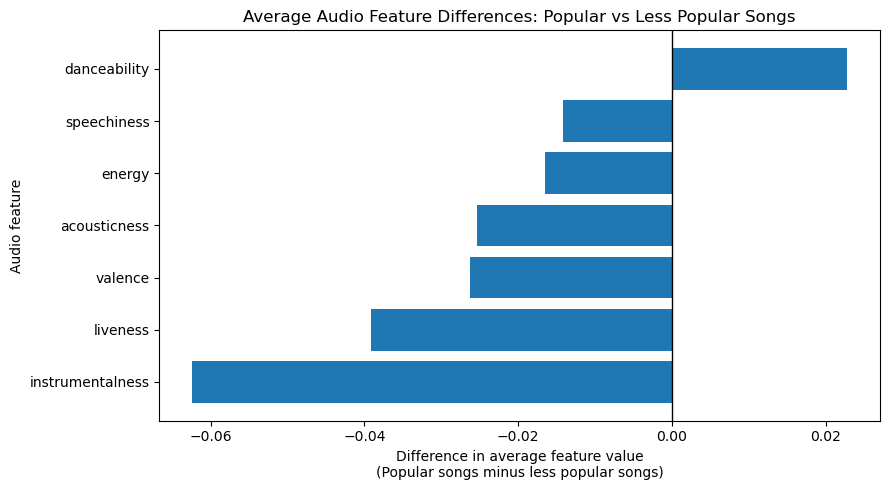

In [232]:
feature_compare_no_duration = df_clean.groupby("popular_song")[[
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness"
]].mean().T

feature_compare_no_duration.columns = ["Less popular", "Popular"]
feature_compare_no_duration["Difference"] = (
    feature_compare_no_duration["Popular"] - feature_compare_no_duration["Less popular"]
)

feature_diff_no_duration = feature_compare_no_duration["Difference"].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(feature_diff_no_duration.index, feature_diff_no_duration.values)
plt.axvline(0, color="black", linewidth=1)

plt.title("Average Audio Feature Differences: Popular vs Less Popular Songs")
plt.xlabel("Difference in average feature value\n(Popular songs minus less popular songs)")
plt.ylabel("Audio feature")
plt.tight_layout()

plt.savefig("figures/audio_feature_differences_no_duration.png", dpi=300)
plt.show()

## Output 5: Correlation Heatmap

This heatmap shows the correlations between Spotify popularity and the selected audio features.

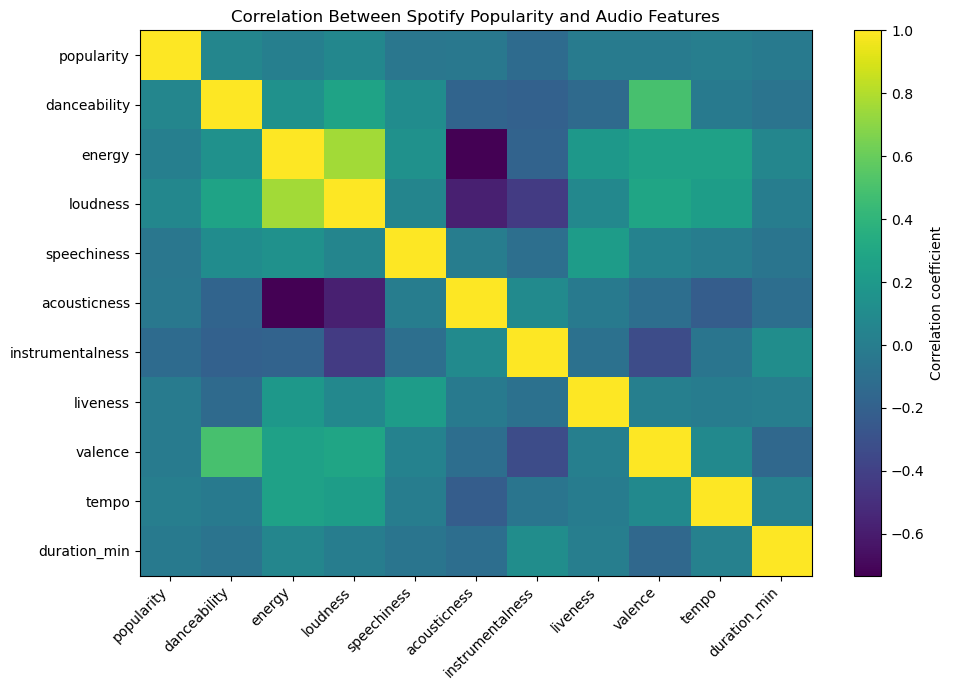

In [235]:
corr_features = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_min"
]

corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(corr_features)), corr_features, rotation=45, ha="right")
plt.yticks(range(len(corr_features)), corr_features)

plt.title("Correlation Between Spotify Popularity and Audio Features")
plt.tight_layout()

plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()

## Output 6: Modelling Popularity

A logistic regression model is used to test whether audio features can predict whether a track belongs to the top 25% of popularity scores.

In [238]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_min", "explicit"
]

X = df_clean[model_features]
y = df_clean["popular_song"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train_scaled, y_train)

y_pred = logit_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7483396478716291

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.86     16805
           1       0.45      0.01      0.03      5630

    accuracy                           0.75     22435
   macro avg       0.60      0.50      0.44     22435
weighted avg       0.68      0.75      0.65     22435


Confusion matrix:
[[16711    94]
 [ 5552    78]]


In [240]:
model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Recall for less popular songs",
        "Recall for popular songs",
        "Precision for popular songs"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        classification_report(y_test, y_pred, output_dict=True)["0"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    ]
})

model_results

,Metric,Value
0,Accuracy,0.748340
1,Recall for less popular songs,0.994406
2,Recall for popular songs,0.013854
3,Precision for popular songs,0.453488


## Output 7: Popularity by Genre

Since audio features alone do not strongly distinguish popular songs, I also examine whether average popularity differs across genres. Genres with fewer than 300 tracks are excluded to avoid drawing conclusions from very small groups.

In [246]:
genre_popularity = (
    df_clean.groupby("track_genre")
    .agg(
        average_popularity=("popularity", "mean"),
        number_of_tracks=("track_id", "count")
    )
    .reset_index()
)

# Keeping genres with enough tracks to avoid tiny-sample weirdness
genre_popularity_filtered = genre_popularity[genre_popularity["number_of_tracks"] >= 300]

top_genres = genre_popularity_filtered.sort_values("average_popularity", ascending=False).head(15)

top_genres

,track_genre,average_popularity,number_of_tracks
65,k-pop,59.423581,916
81,pop-film,59.096933,815
15,chill,53.738683,972
68,latino,51.788945,398
94,sad,51.109929,564
44,grunge,50.587007,862
55,indian,49.765348,733
5,anime,48.776884,995
33,emo,48.500000,932
97,sertanejo,47.860775,826


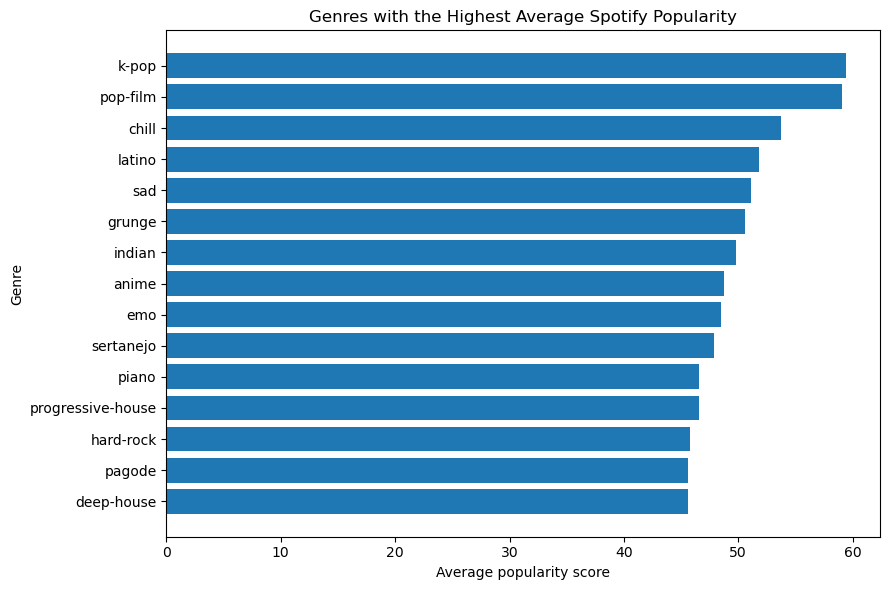

In [252]:
plt.figure(figsize=(9, 6))

plt.barh(top_genres["track_genre"], top_genres["average_popularity"])
plt.gca().invert_yaxis()

plt.title("Genres with the Highest Average Spotify Popularity")
plt.xlabel("Average popularity score")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig("figures/top_genres_by_popularity.png", dpi=300)
plt.show()

## Key Finding

Spotify audio features can explain some differences in song popularity, but they do not provide a simple “hit song formula”. Popular songs in this dataset are slightly more danceable and less instrumental, but the differences are modest rather than dramatic. The logistic regression model also performs poorly at identifying popular songs, suggesting that audio features alone are weak predictors of popularity.

The genre analysis strengthens this conclusion. Average popularity varies noticeably across genres, with k-pop, pop-film, chill and latino among the highest-scoring categories. This suggests that popularity may depend not only on what a song sounds like, but also on genre communities, playlist exposure, artist visibility, marketing, social media attention and release timing.